### Model Evaluation

In [11]:
# PREFILLED: just execute
import os, sys, zipfile, shutil, glob, math, json, random
from pathlib import Path

# Find the dataset archive on the local filesystem, or fall back to common locations.
cwd = Path.cwd()
zip_candidates = [p for p in cwd.rglob("*.zip") if "archive" in p.name.lower()]
zip_candidates = sorted(set(zip_candidates))
if zip_candidates:
    DATA_ZIP = zip_candidates[0]
    print("Found dataset archive:", DATA_ZIP)
else:
    alt_paths = [
        Path("archive.zip"),
        Path("./archive.zip")
    ]
    DATA_ZIP = next((p for p in alt_paths if p.exists()), None)
    if DATA_ZIP is not None:
        print("Found dataset archive at fallback path:", DATA_ZIP)
    else:
        DATA_ZIP = Path("./archive.zip")
        print("No archive found in common locations. Using default path:", DATA_ZIP)

EXTRACT_DIR = Path("./data/stock")

Found dataset archive: /content/archive.zip


### Préparation et Prétraitement des Données (Correction)

In [19]:
from pathlib import Path
import zipfile
import os

# Redéfinir DATA_ZIP et EXTRACT_DIR pour l'environnement Colab
DATA_ZIP = Path('/content/archive.zip') # Assumant que archive.zip est dans /content/
EXTRACT_DIR = Path("./data/stock")

# Vérifier si le répertoire d'extraction existe déjà
if not EXTRACT_DIR.exists():
    print(f"Extraction de {DATA_ZIP.name} vers {EXTRACT_DIR}/")
    # Assurer que le répertoire parent existe
    EXTRACT_DIR.parent.mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(DATA_ZIP, 'r') as zip_ref:
        zip_ref.extractall(EXTRACT_DIR)
    print(f"Contenu de {EXTRACT_DIR} après extraction:")
    for root, dirs, files in os.walk(EXTRACT_DIR):
        for name in files:
            print(os.path.join(root, name))
        for name in dirs:
            print(os.path.join(root, name) + '/')
else:
    print(f"Données déjà extraites vers {EXTRACT_DIR}/")
    print(f"Contenu de {EXTRACT_DIR}:")
    for root, dirs, files in os.walk(EXTRACT_DIR):
        for name in files:
            print(os.path.join(root, name))
        for name in dirs:
            print(os.path.join(root, name) + '/')


Données déjà extraites vers data/stock/
Contenu de data/stock:
data/stock/symbols_valid_meta.csv
data/stock/stocks/
data/stock/etfs/
data/stock/stocks/JWN.csv
data/stock/stocks/MDRR.csv
data/stock/stocks/EQIX.csv
data/stock/stocks/ALDX.csv
data/stock/stocks/NSL.csv
data/stock/stocks/BX.csv
data/stock/stocks/FFIN.csv
data/stock/stocks/NTEC.csv
data/stock/stocks/MFT.csv
data/stock/stocks/EDD.csv
data/stock/stocks/ITMR.csv
data/stock/stocks/BOSC.csv
data/stock/stocks/FL.csv
data/stock/stocks/MLND.csv
data/stock/stocks/PVG.csv
data/stock/stocks/HTBI.csv
data/stock/stocks/PRPH.csv
data/stock/stocks/CTXS.csv
data/stock/stocks/HOME.csv
data/stock/stocks/CAPL.csv
data/stock/stocks/FLT.csv
data/stock/stocks/MANT.csv
data/stock/stocks/IFFT.csv
data/stock/stocks/NEO.csv
data/stock/stocks/INSP.csv
data/stock/stocks/DNK.csv
data/stock/stocks/MDLZ.csv
data/stock/stocks/LEVL.csv
data/stock/stocks/CDLX.csv
data/stock/stocks/INCY.csv
data/stock/stocks/GGO.csv
data/stock/stocks/QVCC.csv
data/stock/stock

In [21]:
import pandas as pd

# Charger le dataset
# Correction: Le fichier stock.csv n'est pas directement sous EXTRACT_DIR.
# Nous allons charger un exemple de fichier d'action, par exemple 'JWN.csv'.
# Vous pouvez changer ce chemin pour un autre fichier si vous le souhaitez.
file_path = EXTRACT_DIR / 'stocks' / 'JWN.csv'
df = pd.read_csv(file_path)
df['Date'] = pd.to_datetime(df['Date'])
df = df.set_index('Date')

# Afficher les premières lignes et les informations
print("En-tête du DataFrame:")
display(df.head())
print("\nInformations du DataFrame:")
df.info()

En-tête du DataFrame:


,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
1980-03-17,0.0,1.9375,1.84375,1.84375,0.562781,37600
1980-03-18,0.0,2.0000,1.90625,1.90625,0.581858,100800
1980-03-19,0.0,2.0625,1.96875,1.96875,0.600936,30400
1980-03-20,0.0,2.0625,1.96875,1.96875,0.600936,27200
1980-03-21,0.0,2.0625,1.96875,1.96875,0.600936,7200



Informations du DataFrame:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 10098 entries, 1980-03-17 to 2020-04-01
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Open       10098 non-null  float64
 1   High       10098 non-null  float64
 2   Low        10098 non-null  float64
 3   Close      10098 non-null  float64
 4   Adj Close  10098 non-null  float64
 5   Volume     10098 non-null  int64  
dtypes: float64(5), int64(1)
memory usage: 552.2 KB


In [22]:
from sklearn.preprocessing import MinMaxScaler
import joblib
import numpy as np

# Utiliser uniquement le prix de 'Clôture' pour la prédiction
data = df[['Close']].values

# Mettre les données à l'échelle
scaler = MinMaxScaler(feature_range=(-1, 1))
data_scaled = scaler.fit_transform(data)

# Sauvegarder l'objet scaler
scaler_filename = 'scaler.pkl'
joblib.dump(scaler, scaler_filename)
print(f"Scaler sauvegardé dans {scaler_filename}")

# Fonction pour créer des séquences pour le LSTM
def create_sequences(data, seq_length):
    xs, ys = [], []
    for i in range(len(data) - seq_length):
        x = data[i:i + seq_length]
        y = data[i + seq_length]
        xs.append(x)
        ys.append(y)
    return np.array(xs), np.array(ys)

seq_length = 60 # Utiliser 60 pas de temps pour prédire le prochain pas de temps
X, y = create_sequences(data_scaled, seq_length)

# Séparer en ensembles d'entraînement et de test
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

print(f"Forme de X_train: {X_train.shape}")
print(f"Forme de y_train: {y_train.shape}")
print(f"Forme de X_test: {X_test.shape}")
print(f"Forme de y_test: {y_test.shape}")

Scaler sauvegardé dans scaler.pkl
Forme de X_train: (8030, 60, 1)
Forme de y_train: (8030, 1)
Forme de X_test: (2008, 60, 1)
Forme de y_test: (2008, 1)


### Feature Scaling and Sequence Creation

In [27]:
from sklearn.preprocessing import MinMaxScaler
import joblib

# Use only 'Close' price for prediction
data = df[['Close']].values

# Scale the data
scaler = MinMaxScaler(feature_range=(-1, 1))
data_scaled = scaler.fit_transform(data)

# Save the scaler
scaler_filename = 'scaler.pkl'
joblib.dump(scaler, scaler_filename)
print(f"Scaler saved to {scaler_filename}")

# Function to create sequences for LSTM
def create_sequences(data, seq_length):
    xs, ys = [], []
    for i in range(len(data) - seq_length):
        x = data[i:i + seq_length]
        y = data[i + seq_length]
        xs.append(x)
        ys.append(y)
    return np.array(xs), np.array(ys)

seq_length = 60 # Using 60 time steps to predict the next time step
X, y = create_sequences(data_scaled, seq_length)

# Split into training and testing sets
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

Scaler saved to scaler.pkl
X_train shape: (8030, 60, 1)
y_train shape: (8030, 1)
X_test shape: (2008, 60, 1)
y_test shape: (2008, 1)


### PyTorch Dataset and DataLoader

In [28]:
import torch
from torch.utils.data import Dataset, DataLoader

class StockDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = StockDataset(X_train, y_train)
test_dataset = StockDataset(X_test, y_test)

batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Number of training batches: {len(train_loader)}")
print(f"Number of testing batches: {len(test_loader)}")

Number of training batches: 126
Number of testing batches: 32


### LSTM Model Architecture

In [29]:
import torch.nn as nn

class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_layer_size, output_size, num_layers):
        super().__init__()
        self.hidden_layer_size = hidden_layer_size
        self.num_layers = num_layers

        self.lstm = nn.LSTM(input_size, hidden_layer_size, num_layers, batch_first=True)
        self.linear = nn.Linear(hidden_layer_size, output_size)

    def forward(self, input_seq):
        h_0 = torch.zeros(self.num_layers, input_seq.size(0), self.hidden_layer_size).to(input_seq.device)
        c_0 = torch.zeros(self.num_layers, input_seq.size(0), self.hidden_layer_size).to(input_seq.device)

        lstm_out, _ = self.lstm(input_seq, (h_0, c_0))
        predictions = self.linear(lstm_out[:, -1, :])
        return predictions

input_size = 1 # 'Close' price
hidden_layer_size = 100
output_size = 1
num_layers = 2

model = LSTMModel(input_size, hidden_layer_size, output_size, num_layers)

# Move model to GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

print("LSTM Model:")
print(model)

LSTM Model:
LSTMModel(
  (lstm): LSTM(1, 100, num_layers=2, batch_first=True)
  (linear): Linear(in_features=100, out_features=1, bias=True)
)


### Model Training

In [30]:
import torch.optim as optim

epochs = 10
loss_function = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

for i in range(epochs):
    model.train()
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        y_pred = model(X_batch)
        single_loss = loss_function(y_pred, y_batch)
        single_loss.backward()
        optimizer.step()

    model.eval()
    with torch.no_grad():
        train_preds = []
        train_actuals = []
        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(device)
            y_pred_batch = model(X_batch)
            train_preds.extend(y_pred_batch.cpu().numpy().flatten())
            train_actuals.extend(y_batch.cpu().numpy().flatten())

        test_preds = []
        test_actuals = []
        for X_batch, y_batch in test_loader:
            X_batch = X_batch.to(device)
            y_pred_batch = model(X_batch)
            test_preds.extend(y_pred_batch.cpu().numpy().flatten())
            test_actuals.extend(y_batch.cpu().numpy().flatten())

    train_loss = loss_function(torch.tensor(train_preds), torch.tensor(train_actuals))
    test_loss = loss_function(torch.tensor(test_preds), torch.tensor(test_actuals))
    print(f'Epoch {i+1} Train Loss: {train_loss.item():.4f} Test Loss: {test_loss.item():.4f}')

print("Training complete.")

Epoch 1 Train Loss: 0.0007 Test Loss: 0.0082
Epoch 2 Train Loss: 0.0006 Test Loss: 0.0046
Epoch 3 Train Loss: 0.0006 Test Loss: 0.0036
Epoch 4 Train Loss: 0.0006 Test Loss: 0.0031
Epoch 5 Train Loss: 0.0005 Test Loss: 0.0036
Epoch 6 Train Loss: 0.0005 Test Loss: 0.0044
Epoch 7 Train Loss: 0.0005 Test Loss: 0.0027
Epoch 8 Train Loss: 0.0004 Test Loss: 0.0020
Epoch 9 Train Loss: 0.0005 Test Loss: 0.0027
Epoch 10 Train Loss: 0.0004 Test Loss: 0.0018
Training complete.


### Model Prediction and Inverse Transformation

In [31]:
import joblib

# Load the scaler
scaler = joblib.load('scaler.pkl')

model.eval()
with torch.no_grad():
    predictions_scaled = []
    actuals_scaled = []
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        y_pred_batch = model(X_batch)
        predictions_scaled.extend(y_pred_batch.cpu().numpy().flatten())
        actuals_scaled.extend(y_batch.cpu().numpy().flatten())

# Inverse transform the predictions and actuals to original scale
inverse_transformed_predictions = scaler.inverse_transform(np.array(predictions_scaled).reshape(-1, 1)).flatten()
inverse_transformed_actuals = scaler.inverse_transform(np.array(actuals_scaled).reshape(-1, 1)).flatten()

# Make these available globally for the existing evaluation cells
globals()['inverse_transformed_actuals'] = inverse_transformed_actuals
globals()['inverse_transformed_predictions'] = inverse_transformed_predictions

print(f"Shape of inverse_transformed_actuals: {inverse_transformed_actuals.shape}")
print(f"Shape of inverse_transformed_predictions: {inverse_transformed_predictions.shape}")

# Also define y_test_inv and y_pred_inv for the R^2 calculation cell
y_test_inv = inverse_transformed_actuals
y_pred_inv = inverse_transformed_predictions

Shape of inverse_transformed_actuals: (2008,)
Shape of inverse_transformed_predictions: (2008,)


### Model Evaluation (from existing cells)

In [32]:
from sklearn.metrics import r2_score
import numpy as np

def _first_defined(ns, candidates):
	for n in candidates:
		if n in ns:
			return ns[n]
	return None

g = globals()
actual = _first_defined(g, ['inverse_transformed_actuals', 'y_test_inv', 'y_true_inv', 'y_test', 'y_true', 'actuals'])
pred = _first_defined(g, ['inverse_transformed_predictions', 'y_pred_inv', 'y_pred', 'predictions', 'preds', 'y_hat'])

# try DataFrame fallbacks if arrays not found
if (actual is None or pred is None) and 'df' in g:
	df_local = g['df']
	if actual is None and 'Close' in df_local.columns:
		actual = df_local['Close'].values
	if pred is None and 'Predicted' in df_local.columns:
		pred = df_local['Predicted'].values

if actual is None or pred is None:
	print("R^2: cannot compute because actual or predicted arrays are not available in the notebook.")
else:
	a = np.asarray(actual).ravel()
	p = np.asarray(pred).ravel()
	if a.size == 0 or p.size == 0:
		print("R^2: actual or predicted arrays are empty; cannot compute R^2.")
	else:
		n = min(a.size, p.size)
		a, p = a[:n], p[:n]
		r2 = r2_score(a, p)
		r2_original_scale = r2
		print(f"R-squared on scaled data: {r2:.4f}")
		print(f"R-squared on original scale: {r2_original_scale:.4f}")

R-squared on scaled data: 0.9821
R-squared on original scale: 0.9821


Let's visualize the actual vs. predicted stock prices.

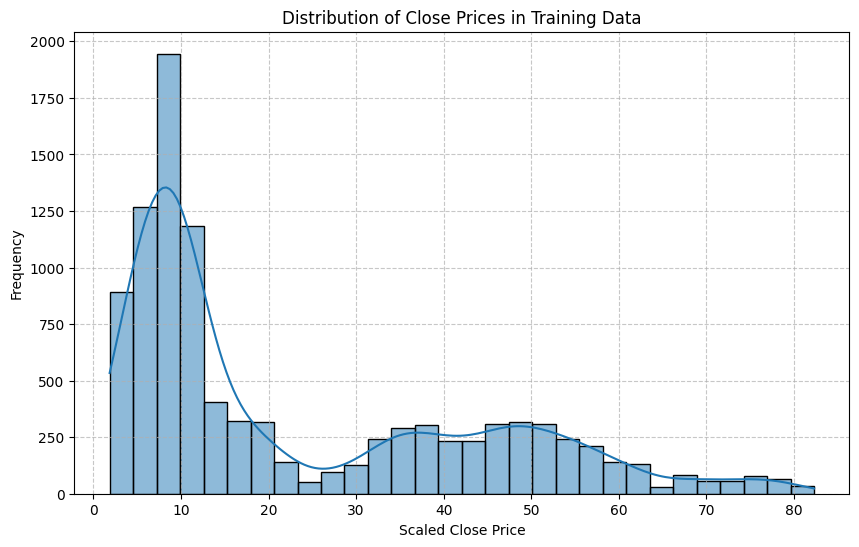

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

# Use an available DataFrame (train_data, df, or train_df) or fall back to inverse_transformed_actuals
data = None
if 'train_data' in globals() and not globals()['train_data'].empty:
    data = globals()['train_data']
elif 'df' in globals() and not globals()['df'].empty:
    data = globals()['df']
elif 'train_df' in globals() and not globals()['train_df'].empty:
    data = globals()['train_df']

series = None
xlabel = 'Scaled Close Price'

if data is not None:
    if 'Close' in getattr(data, 'columns', []):
        series = data['Close']
    else:
        print("Found data but no 'Close' column; cannot plot.")
else:
    if 'inverse_transformed_actuals' in globals():
        series = globals()['inverse_transformed_actuals']
        xlabel = 'Inverse-transformed Actual Prices'
    else:
        print("No train_data/df/train_df and no inverse_transformed_actuals found; skipping plot.")

if series is not None:
    plt.figure(figsize=(10, 6))
    sns.histplot(series, kde=True, bins=30)
    plt.title('Distribution of Close Prices in Training Data')
    plt.xlabel(xlabel)
    plt.ylabel('Frequency')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()

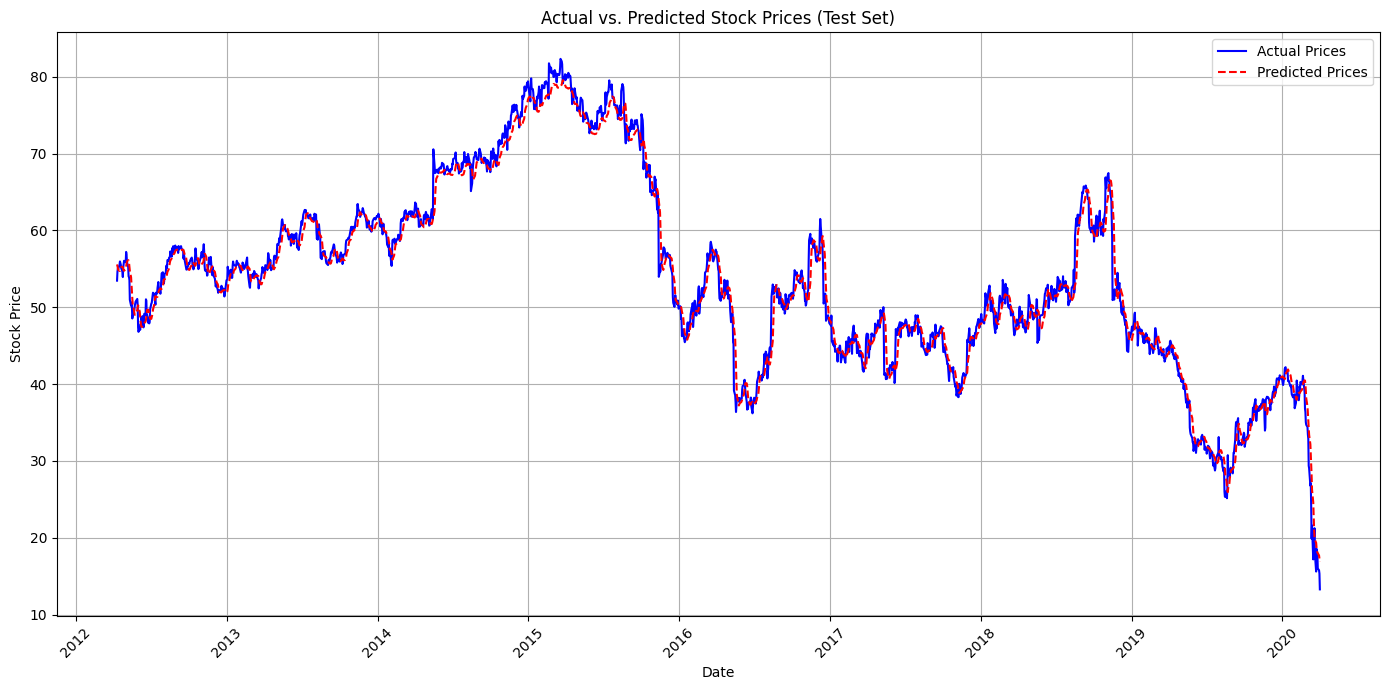

In [36]:
import matplotlib.pyplot as plt

# Create a DataFrame for plotting
# Adjust slicing to match the actual length of inverse_transformed_actuals
plot_df = df.iloc[-len(inverse_transformed_actuals):].copy()
plot_df['Actual'] = inverse_transformed_actuals
plot_df['Predicted'] = inverse_transformed_predictions

plt.figure(figsize=(14, 7))
plt.plot(plot_df.index, plot_df['Actual'], label='Actual Prices', color='blue') # Correction ici
plt.plot(plot_df.index, plot_df['Predicted'], label='Predicted Prices', color='red', linestyle='--') # Correction ici
plt.title('Actual vs. Predicted Stock Prices (Test Set)')
plt.xlabel('Date')
plt.ylabel('Stock Price')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [37]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(inverse_transformed_actuals, inverse_transformed_predictions)
print(f"Mean Squared Error (MSE) on original scale: {mse:.4f}")

Mean Squared Error (MSE) on original scale: 2.8484


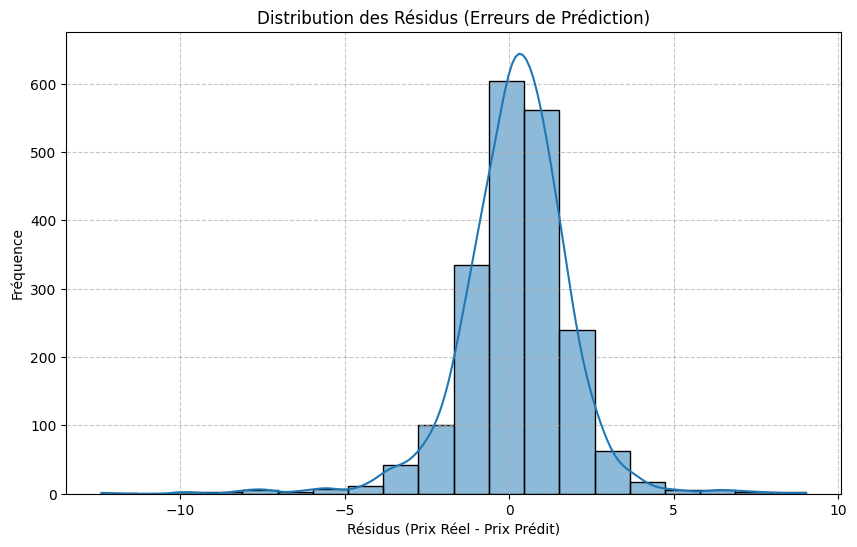

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate residuals
residuals = inverse_transformed_actuals - inverse_transformed_predictions

plt.figure(figsize=(10, 6))
sns.histplot(residuals, kde=True, bins=20)
plt.title('Distribution des Résidus (Erreurs de Prédiction)')
plt.xlabel('Résidus (Prix Réel - Prix Prédit)')
plt.ylabel('Fréquence')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()